# Gold Visualization

## Import libraries

In [57]:
import os
import sys
import pandas as pd
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from visualizer.visualizer import Visualizer
from model.arima_model import ArimaModel
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Initialize the Logger

In [18]:
my_logger = Logger(file_name=ARIMA_VISUALIZATION_LOG_FILE_BASE)

## Initialize the Visualizer

In [19]:
my_visualizer = Visualizer(logger=my_logger)

## Initialize the ArimaModel

In [20]:
arima_model = ArimaModel(logger=my_logger)

## Parameters

In [21]:
value_column_name = "#Passengers"

## Load data

In [22]:
df = pd.read_csv("AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


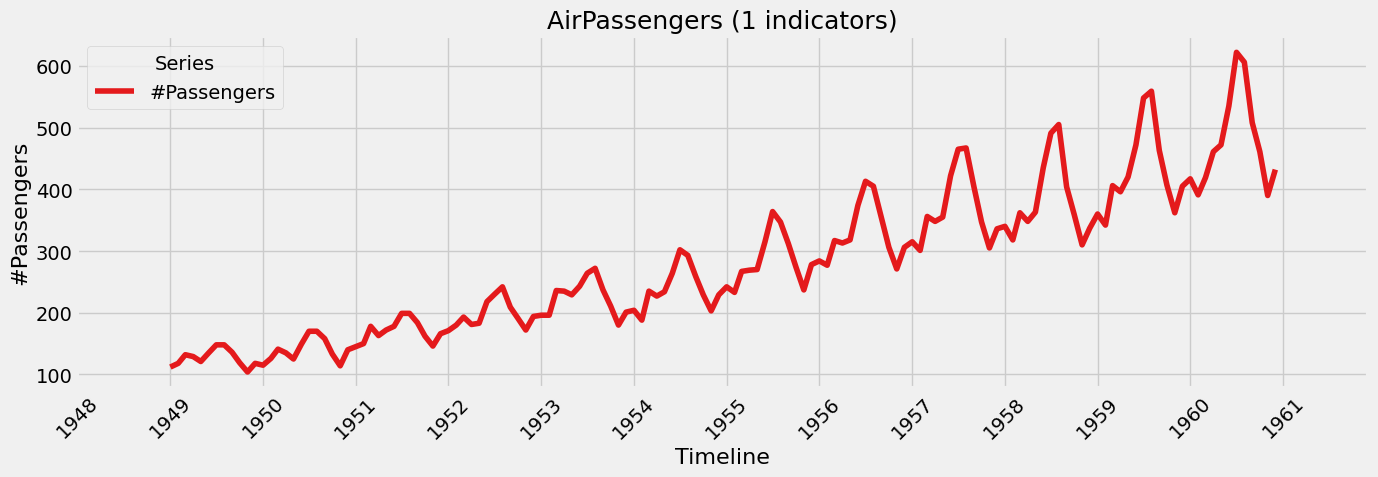

In [23]:
my_visualizer.plot_lines_chart(
    df,
    x_column="Month",
    y_columns=[value_column_name],
    title="AirPassengers",
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name="AirPassengers",
    marker=None,
)

## First check whether the time series is stationary

In [24]:
arima_model._is_stationary(df[value_column_name])

d:\DATA SCIENCE\GIT\master-thesis\src\model\arima_model.py:52: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, nlags, crit = kpss(series.dropna(), regression="c", nlags="auto")


(np.False_,
 {'adf': {'statistic': np.float64(0.8153688792060482),
   'pvalue': np.float64(0.991880243437641),
   'nlags': 13,
   'nobs': 130,
   'stationary': np.False_},
  'kpss': {'statistic': np.float64(1.6513122354165206),
   'pvalue': np.float64(0.01),
   'nlags': 8,
   'stationary': np.False_}})

## Fit the model

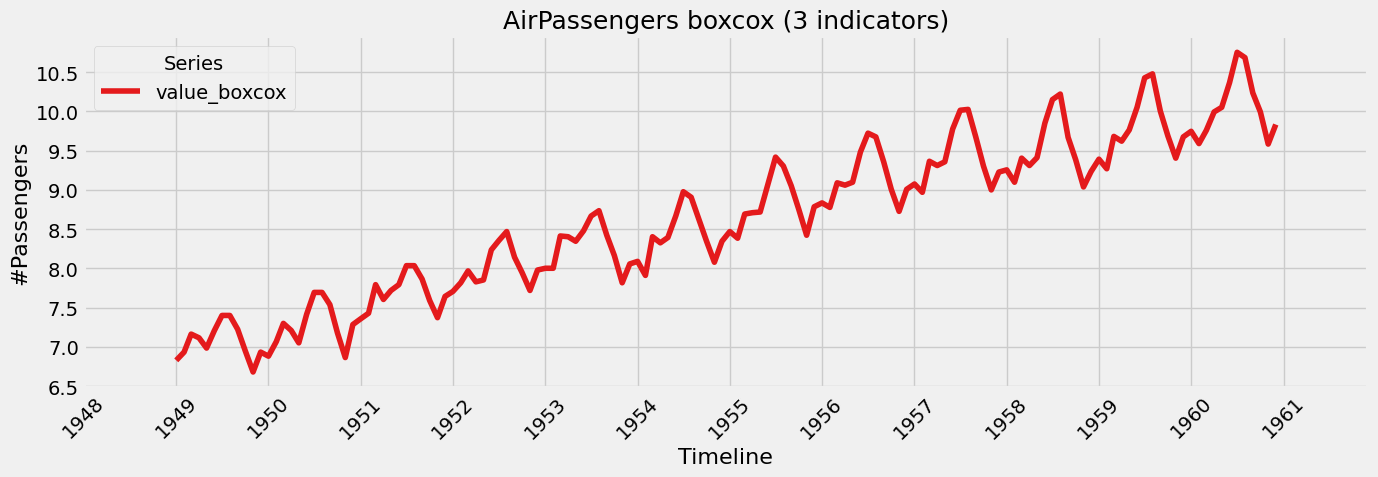

In [39]:
df["value_boxcox"], best_lambda = boxcox(df[value_column_name])
my_visualizer.plot_lines_chart(
    df,
    x_column="Month",
    y_columns=["value_boxcox"],
    title="AirPassengers boxcox",
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name="AirPassengers boxcox",
    marker=None,
)

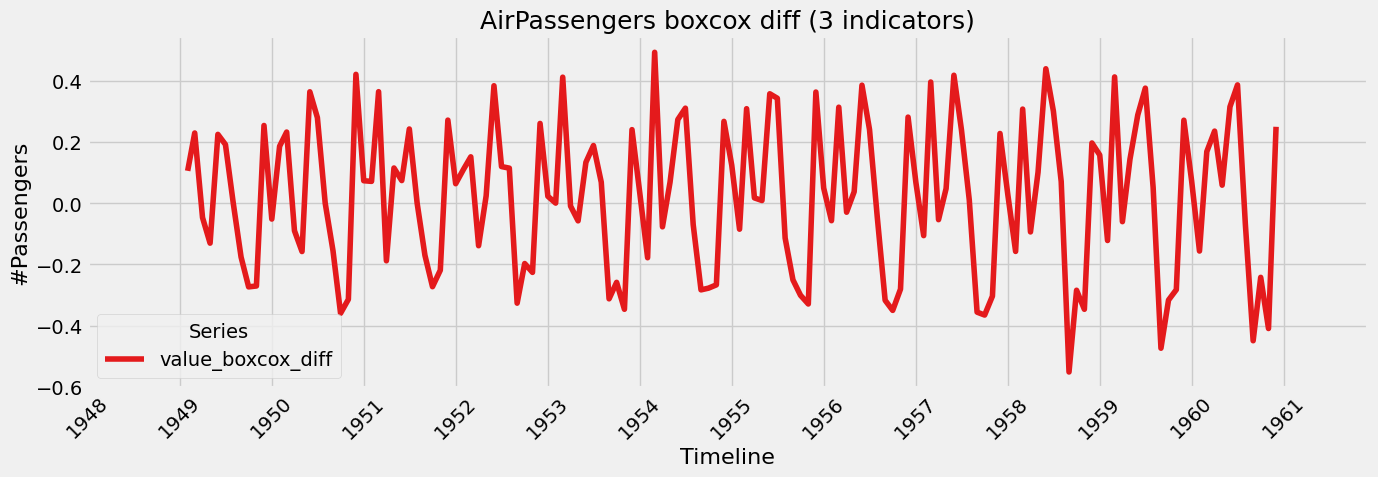

In [41]:
df["value_boxcox_diff"] = df["value_boxcox"].diff()
my_visualizer.plot_lines_chart(
    df,
    x_column="Month",
    y_columns=["value_boxcox_diff"],
    title="AirPassengers boxcox diff",
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name="AirPassengers boxcox diff",
    marker=None,
)

In [53]:
df.dropna(inplace=True)

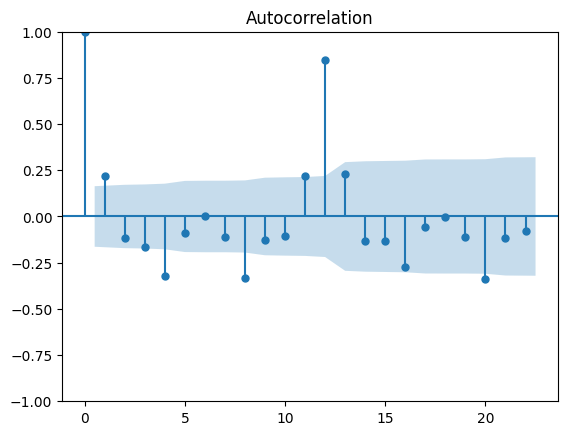

In [54]:
plot_acf(df['value_boxcox_diff'])

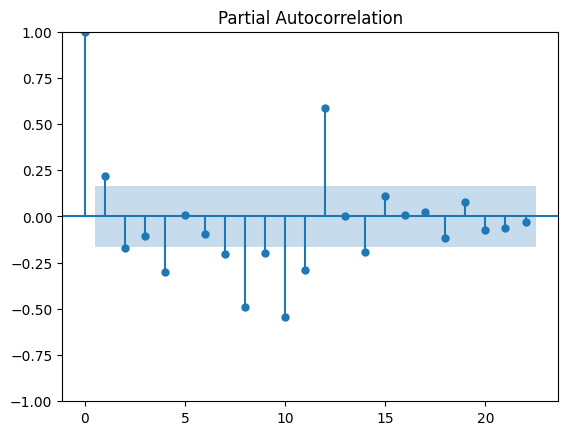

In [55]:
plot_pacf(df['value_boxcox_diff'], method='ywm')

In [59]:
# Split train and test
train = df.iloc[:-int(len(df) * 0.2)]
test = df.iloc[-int(len(df) * 0.2):]

In [61]:
model = ARIMA(train['value_boxcox'], order=(12, 1, 12)).fit()

d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966

In [63]:
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, best_lambda)

d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [64]:
df["forecasts"] = forecasts

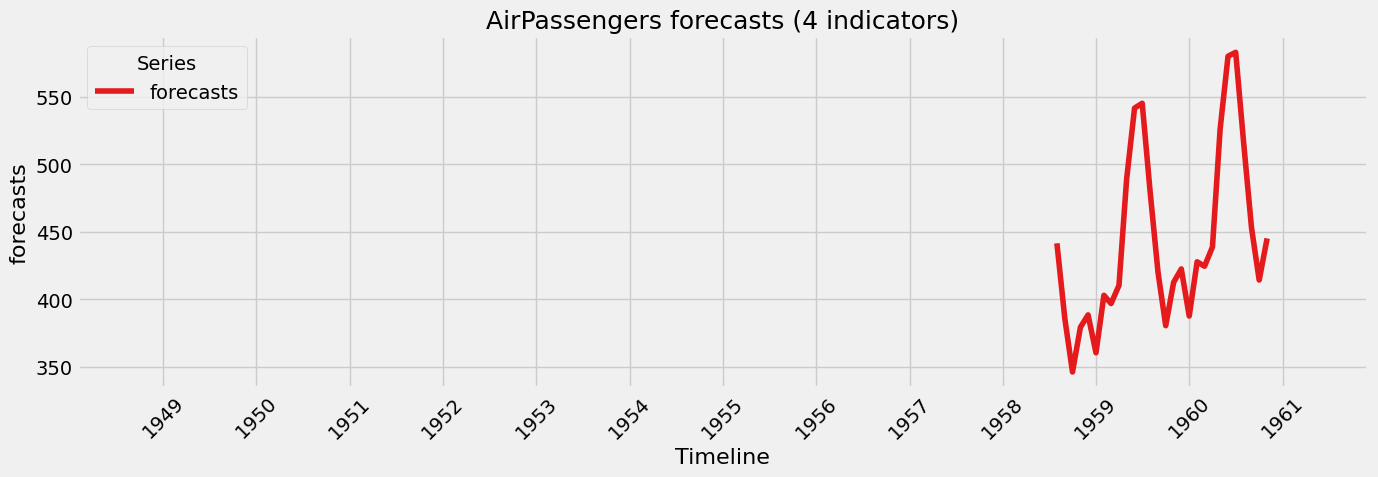

In [65]:
my_visualizer.plot_lines_chart(
    df,
    x_column="Month",
    y_columns=["forecasts"],
    title="AirPassengers forecasts",
    y_axis_title="forecasts",
    y_unit="",
    prefix_figure_name="AirPassengers_forecasts",
    marker=None,
)

d:\DATA SCIENCE\GIT\master-thesis\src\visualizer\visualizer.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x_column] = pd.to_datetime(df[x_column])


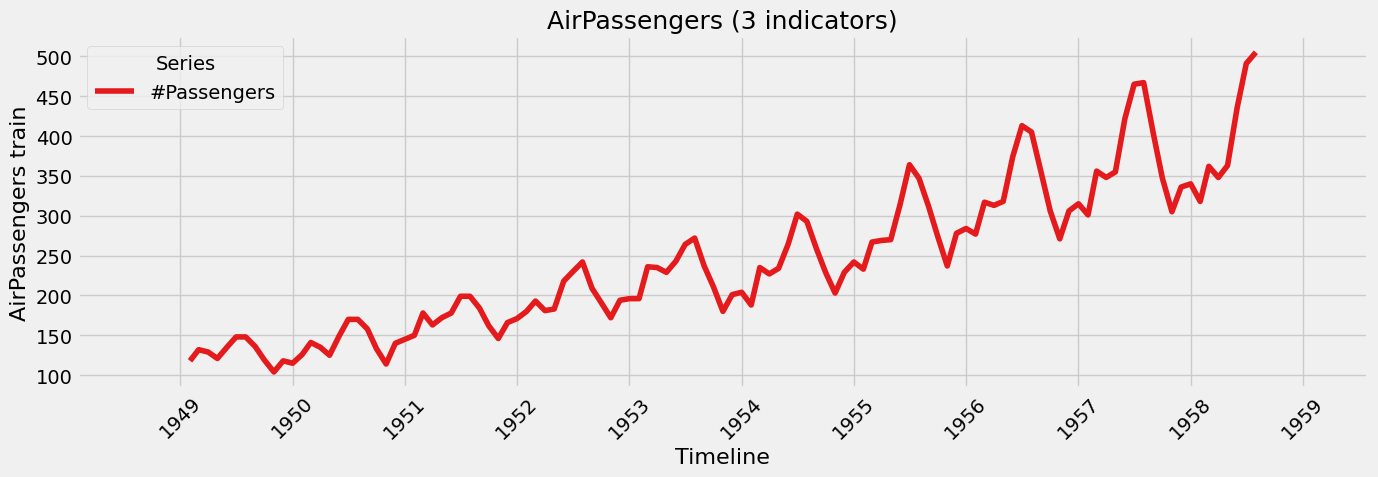

In [67]:
my_visualizer.plot_lines_chart(
    train,
    x_column="Month",
    y_columns=["#Passengers"],
    title="AirPassengers",
    y_axis_title="AirPassengers train",
    y_unit="",
    prefix_figure_name="AirPassengers_train",
    marker=None,
)